In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Unemployment in India.csv")
print(df.head())
print(df.info())
df.columns
df.isnull().sum()

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data colu

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [3]:
df.columns = df.columns.str.strip()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [12]:
#converting data column 
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

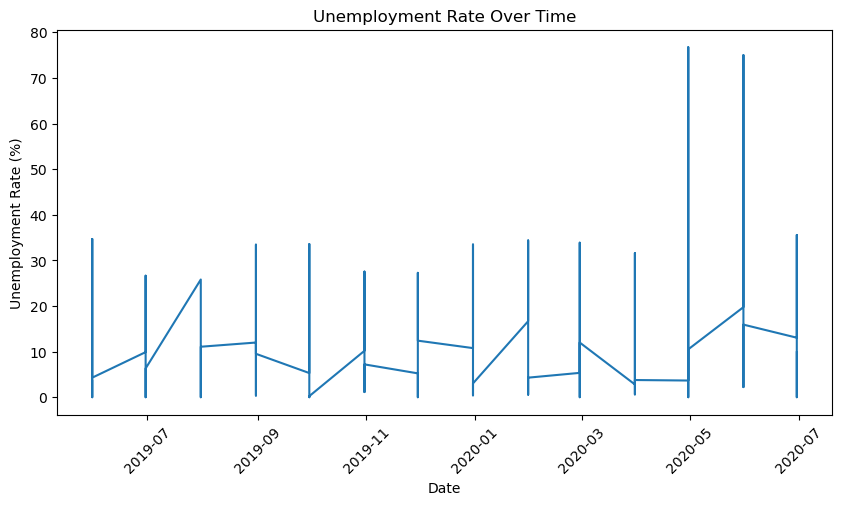

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

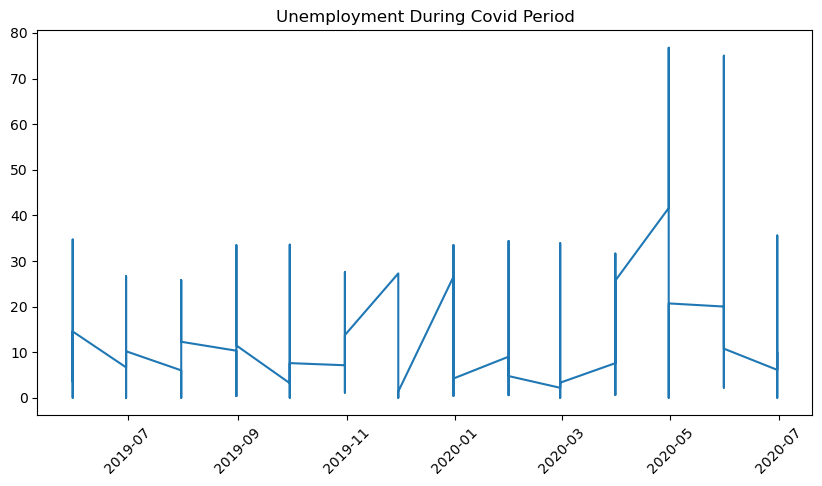

In [9]:
covid_df = df[(df['Date'] >= '2019-01-01') & 
              (df['Date'] <= '2021-12-31')]

plt.figure(figsize=(10,5))
plt.plot(covid_df['Date'], covid_df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment During Covid Period")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [6]:
df['Region'].unique()

array(['Andhra Pradesh', 'Telangana', 'Tamil Nadu', 'Rajasthan', 'Punjab',
       'Puducherry', 'Odisha', 'Meghalaya', 'Maharashtra',
       'Madhya Pradesh', 'Kerala', 'Tripura', 'Karnataka', 'Jharkhand',
       'Jammu & Kashmir', 'Uttar Pradesh', 'Himachal Pradesh', 'Haryana',
       'Uttarakhand', 'Gujarat', 'Goa', 'Delhi', 'Chhattisgarh',
       'Chandigarh', 'Bihar', 'Assam', 'West Bengal', 'Sikkim', nan],
      dtype=object)

In [7]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_avg.sort_values(ascending=False)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

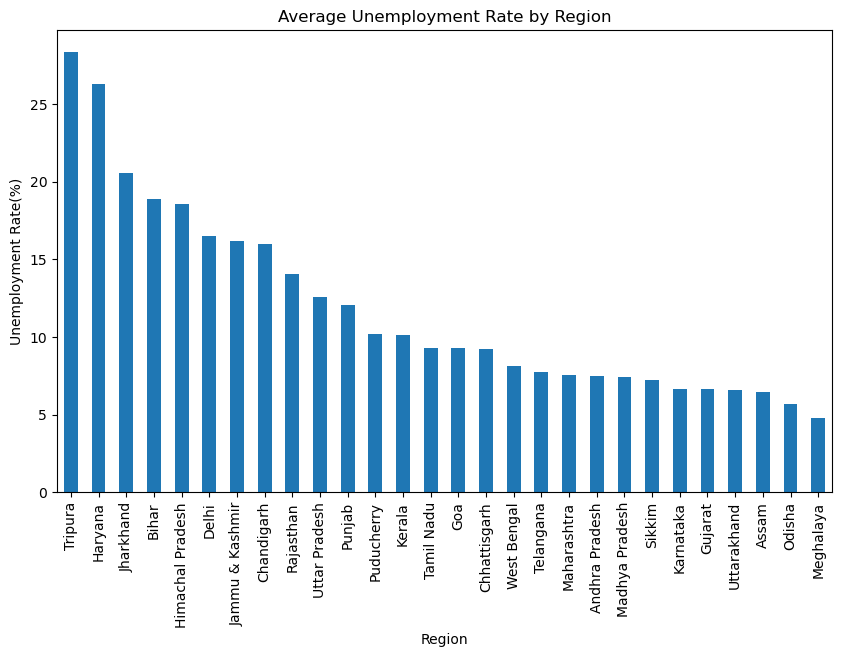

In [8]:
plt.figure(figsize=(10,6))
region_avg.sort_values(ascending=False).plot(kind='bar')
plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate(%)")
plt.show()


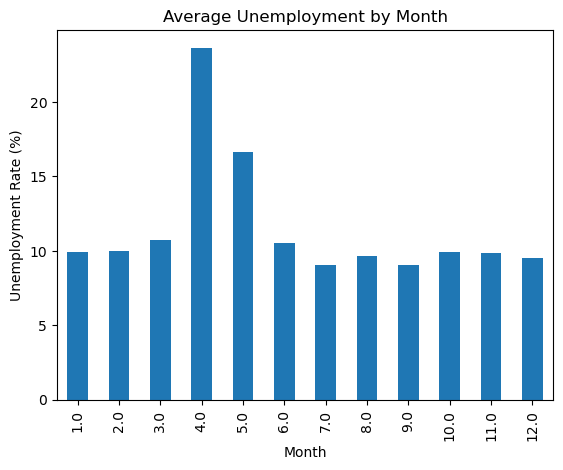

In [9]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg.plot(kind='bar')
plt.title("Average Unemployment by Month")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [10]:
pivot_table = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)


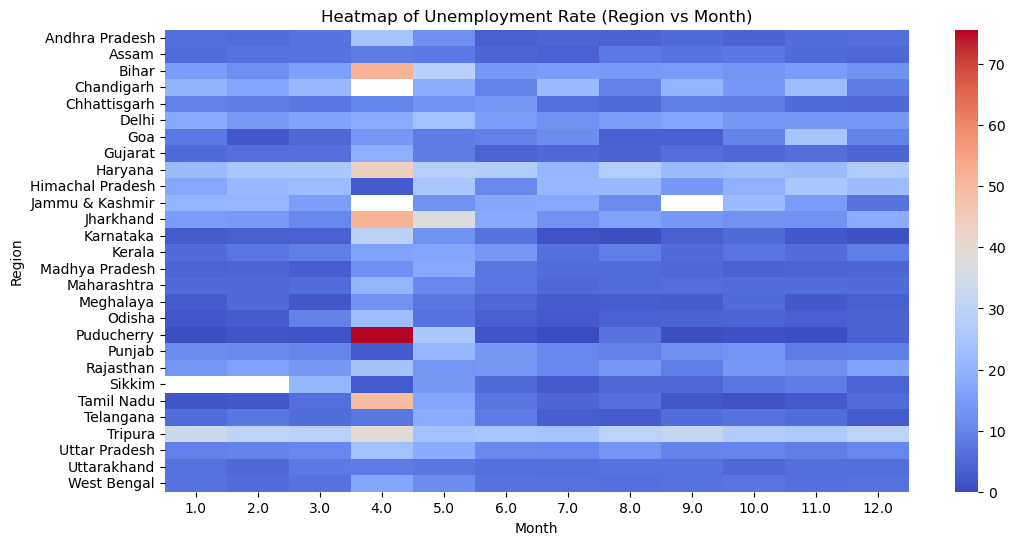

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("Heatmap of Unemployment Rate (Region vs Month)")
plt.show()

In [1]:
import os
print(os.getcwd())

C:\Users\Pavan kumar\CodeAlpha_Unemployment Analysis
